/var/folders/9d/7216hsv562lbddcy7qb278zc0000gp/T/ipykernel_6337/4250465806.py:24: MarkupResemblesLocatorWarning: The input passed in on this line looks more like a URL than HTML or XML.

If you meant to use Beautiful Soup to parse the web page found at a certain URL, then something has gone wrong. You should use an Python package like 'requests' to fetch the content behind the URL. Once you have the content as a string, you can feed that string into Beautiful Soup.

However, if you want to parse some data that happens to look like a URL, then nothing has gone wrong: you are using Beautiful Soup correctly, and this warning is spurious and can be filtered. To make this warning go away, run this code before calling the BeautifulSoup constructor:

    from bs4 import MarkupResemblesLocatorWarning
    import warnings

    warnings.filterwarnings("ignore", category=MarkupResemblesLocatorWarning)
    
  text = BeautifulSoup(str(text), "html.parser").get_text()



Summary Stats for Ratings and Helpful Votes:

        star_rating  helpful_votes   total_votes
count  49971.000000   49971.000000  49971.000000
mean       3.968822       1.650717      1.952693
std        1.401930       9.555778     10.072284
min        1.000000       0.000000      0.000000
25%        3.000000       0.000000      0.000000
50%        5.000000       0.000000      0.000000
75%        5.000000       1.000000      1.000000
max        5.000000     628.000000    634.000000

Correlation Matrix:
                           star_rating  helpful_votes  total_votes  \
star_rating                  1.000000       0.010724    -0.001115   
helpful_votes                0.010724       1.000000     0.992122   
total_votes                 -0.001115       0.992122     1.000000   
verified_purchase_binary    -0.115033      -0.019860    -0.027789   

                          verified_purchase_binary  
star_rating                              -0.115033  
helpful_votes                         

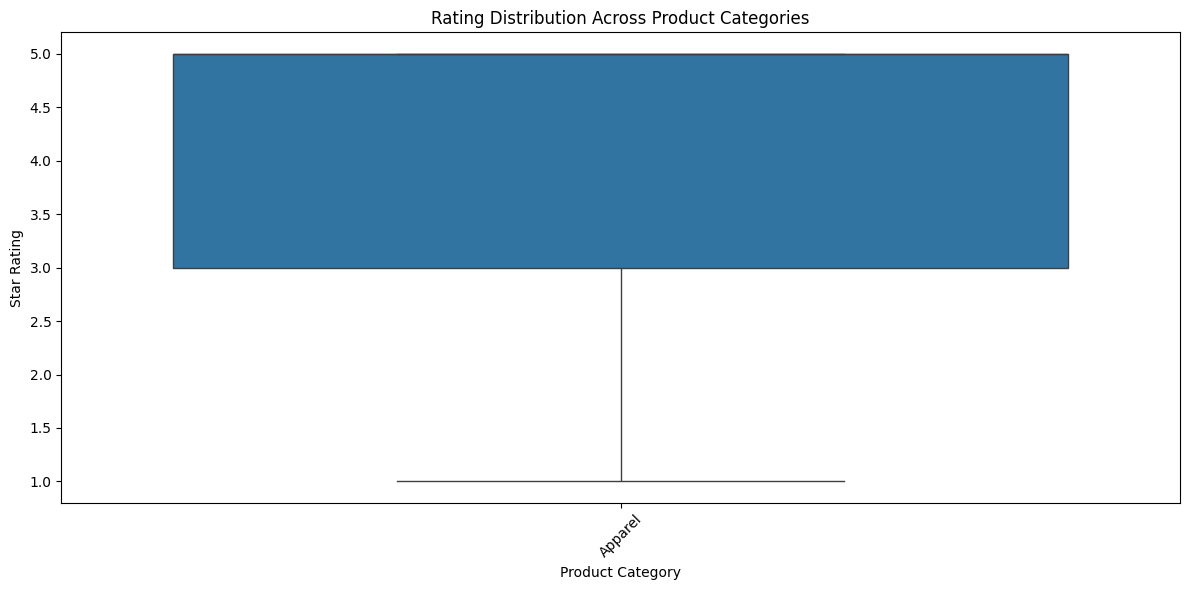


Central Tendency & Dispersion for star_rating:
Mean: 3.97, Median: 5.0, Mode: 5, Std Dev: 1.40

Hypothesis Test: Verified vs Non-Verified Star Ratings
T-Statistic: -28.114, P-Value: 0.0000
=> Statistically significant: Verified purchases have different ratings.

Bayesian Probability P(helpful | total_votes > 0): 0.8323


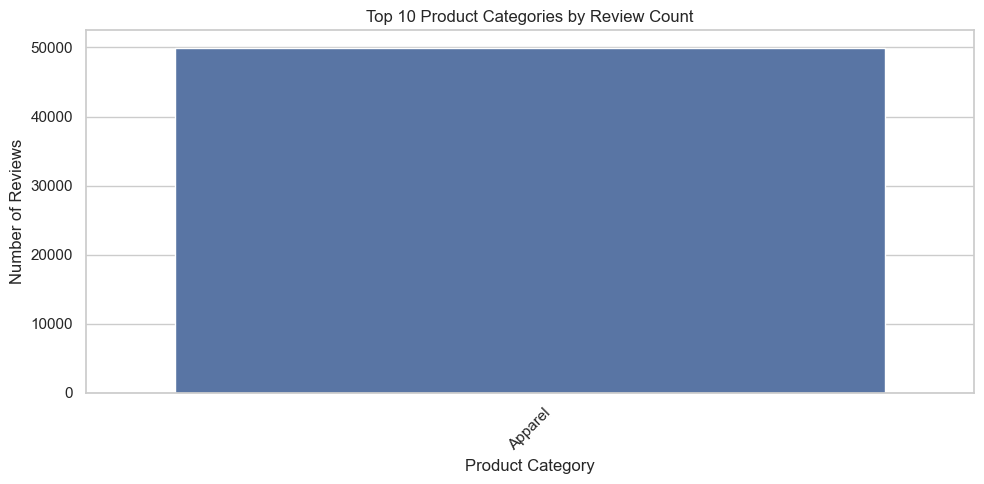

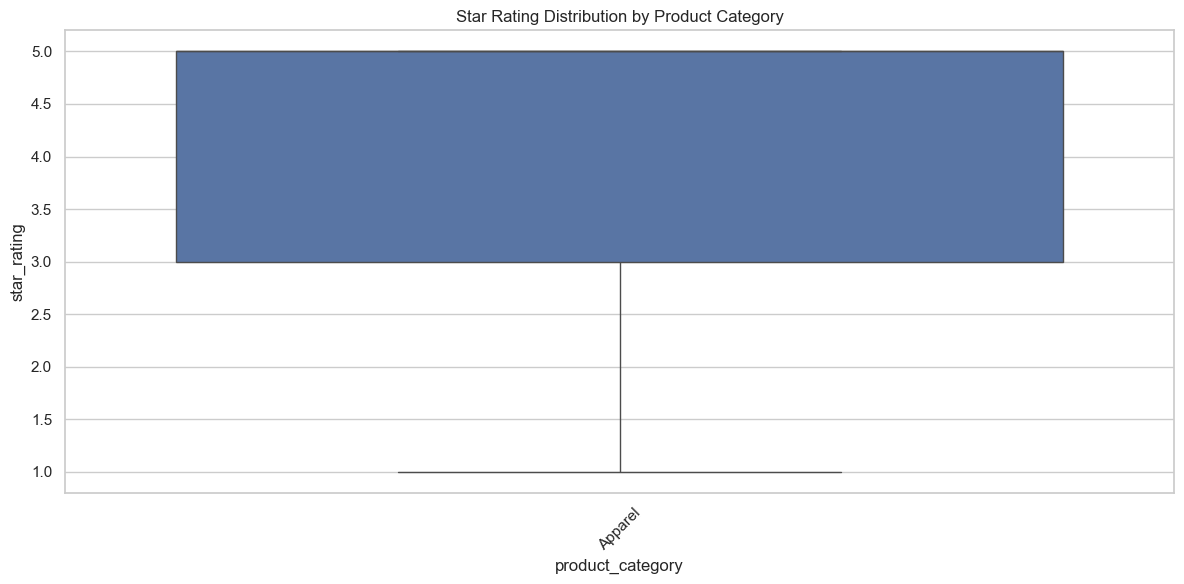

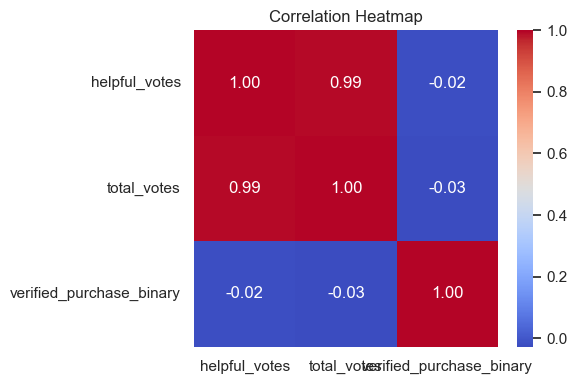

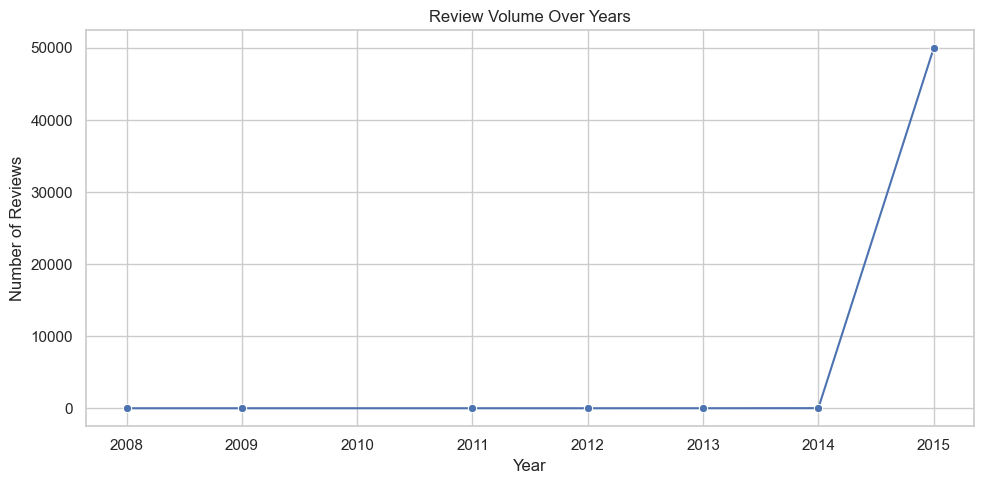


Feature Engineering Summary:
   review_length  verified_purchase_binary  vine_binary  total_votes_scaled  \
0            523                         1            0            0.000000   
1             69                         1            0            0.003155   
2             15                         1            0            0.000000   
3             31                         1            0            0.000000   
4              8                         1            0            0.000000   

   helpful_votes_scaled  review_length_scaled  
0              0.000000              0.417398  
1              0.001592              0.055068  
2              0.000000              0.011971  
3              0.000000              0.024741  
4              0.000000              0.006385  


In [3]:
# Section 1: Data analysis and preprocessing

import pandas as pd
import numpy as np
import re
from bs4 import BeautifulSoup
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder


# Load data
df = pd.read_csv("amazon_reviews_us_Apparel_v1_00.csv", nrows=50000)

# STEP 1: Preprocessing
df = df.dropna(subset=["review_body", "star_rating", "verified_purchase"])
df['review_date'] = pd.to_datetime(df['review_date'], errors='coerce', dayfirst=True)
df['review_year'] = df['review_date'].dt.year
df['review_month'] = df['review_date'].dt.month
df['review_dayofweek'] = df['review_date'].dt.day_name()

def clean_text(text):
    text = BeautifulSoup(str(text), "html.parser").get_text()
    text = re.sub(r"[^a-zA-Z0-9\s.,!?]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip().lower()

df['cleaned_review_body'] = df['review_body'].apply(clean_text)

# STEP 2: EDA
print("\nSummary Stats for Ratings and Helpful Votes:\n")
print(df[['star_rating', 'helpful_votes', 'total_votes']].describe())

# Add binary flag for verified purchase
df['verified_purchase_binary'] = df['verified_purchase'].map({'Y': 1, 'N': 0})

# Correlation matrix
corr_matrix = df[['star_rating', 'helpful_votes', 'total_votes', 'verified_purchase_binary']].corr()
print("\nCorrelation Matrix:\n", corr_matrix)

# Most and least reviewed products
review_counts = df['product_id'].value_counts()
most_reviewed = review_counts.head(5)
least_reviewed = review_counts.tail(5)

print("\nMost Reviewed Products:\n", most_reviewed)
print("\nLeast Reviewed Products:\n", least_reviewed)

# Rating distribution by product category
plt.figure(figsize=(12, 6))
sns.boxplot(x='product_category', y='star_rating', data=df)
plt.xticks(rotation=45)
plt.title("Rating Distribution Across Product Categories")
plt.xlabel("Product Category")
plt.ylabel("Star Rating")
plt.tight_layout()
plt.show()


# STEP 3.1: Measures of central tendency and dispersion for star_rating
mean_rating = df['star_rating'].mean()
median_rating = df['star_rating'].median()
mode_rating = df['star_rating'].mode()[0]
std_rating = df['star_rating'].std()

print("\nCentral Tendency & Dispersion for star_rating:")
print(f"Mean: {mean_rating:.2f}, Median: {median_rating}, Mode: {mode_rating}, Std Dev: {std_rating:.2f}")

# STEP 3.2: Hypothesis Testing - Do verified purchases have higher ratings?
verified = df[df['verified_purchase'] == 'Y']['star_rating']
not_verified = df[df['verified_purchase'] == 'N']['star_rating']

t_stat, p_value = stats.ttest_ind(verified, not_verified, equal_var=False)
print("\nHypothesis Test: Verified vs Non-Verified Star Ratings")
print(f"T-Statistic: {t_stat:.3f}, P-Value: {p_value:.4f}")
if p_value < 0.05:
    print("=> Statistically significant: Verified purchases have different ratings.")
else:
    print("=> Not statistically significant: No difference in ratings.")

# STEP 3.3: Bayesian Probability - Likelihood of a review being helpful
# P(helpful | total_votes > 0) = (# helpful_votes > 0 and total_votes > 0) / (# total_votes > 0)
df_votes = df[df['total_votes'] > 0]
helpful_given_voted = (df_votes['helpful_votes'] > 0).sum() / len(df_votes)

print(f"\nBayesian Probability P(helpful | total_votes > 0): {helpful_given_voted:.4f}")

import matplotlib.pyplot as plt
import seaborn as sns

# Set consistent style
sns.set(style="whitegrid")

# STEP 4.1: Bar chart - most popular product categories by review count
plt.figure(figsize=(10, 5))
top_categories = df['product_category'].value_counts().head(10)
sns.barplot(x=top_categories.index, y=top_categories.values)
plt.title("Top 10 Product Categories by Review Count")
plt.xlabel("Product Category")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# STEP 4.2: Box plot - distribution of star ratings across categories
plt.figure(figsize=(12, 6))
sns.boxplot(x='product_category', y='star_rating', data=df)
plt.title("Star Rating Distribution by Product Category")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# STEP 4.3: Heatmap - correlation of helpful_votes, total_votes, and verified_purchase_binary
corr_features = df[['helpful_votes', 'total_votes', 'verified_purchase_binary']].corr()
plt.figure(figsize=(6, 4))
sns.heatmap(corr_features, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# STEP 4.4: Time series line chart - number of reviews over time (by year)
plt.figure(figsize=(10, 5))
reviews_by_year = df['review_year'].value_counts().sort_index()
sns.lineplot(x=reviews_by_year.index, y=reviews_by_year.values, marker='o')
plt.title("Review Volume Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()


# STEP 5.1: Create review_length feature
df['review_length'] = df['cleaned_review_body'].apply(lambda x: len(str(x).split()))

# STEP 5.2: Convert 'verified_purchase' and 'vine' to numerical format
df['verified_purchase_binary'] = df['verified_purchase'].map({'Y': 1, 'N': 0})
df['vine_binary'] = df['vine'].map({'Y': 1, 'N': 0})

# STEP 5.3: One-hot encode 'product_category'
df = pd.get_dummies(df, columns=['product_category'], drop_first=True)

# STEP 5.4: Normalize numerical features (total_votes, helpful_votes, review_length)
scaler = MinMaxScaler()
df[['total_votes_scaled', 'helpful_votes_scaled', 'review_length_scaled']] = scaler.fit_transform(
    df[['total_votes', 'helpful_votes', 'review_length']]
)

# Confirm engineered features
print("\nFeature Engineering Summary:")
print(df[['review_length', 'verified_purchase_binary', 'vine_binary',
          'total_votes_scaled', 'helpful_votes_scaled', 'review_length_scaled']].head())






Linear:
R2: 0.35099725240778246
MSE: 1.2873568764513583
RMSE: 1.1346175022673317

Ridge:
R2: 0.35099433968221583
MSE: 1.2873626541114704
RMSE: 1.13462004834723

Lasso:
R2: 0.2884416621165855
MSE: 1.411441665954354
RMSE: 1.1880411044885417


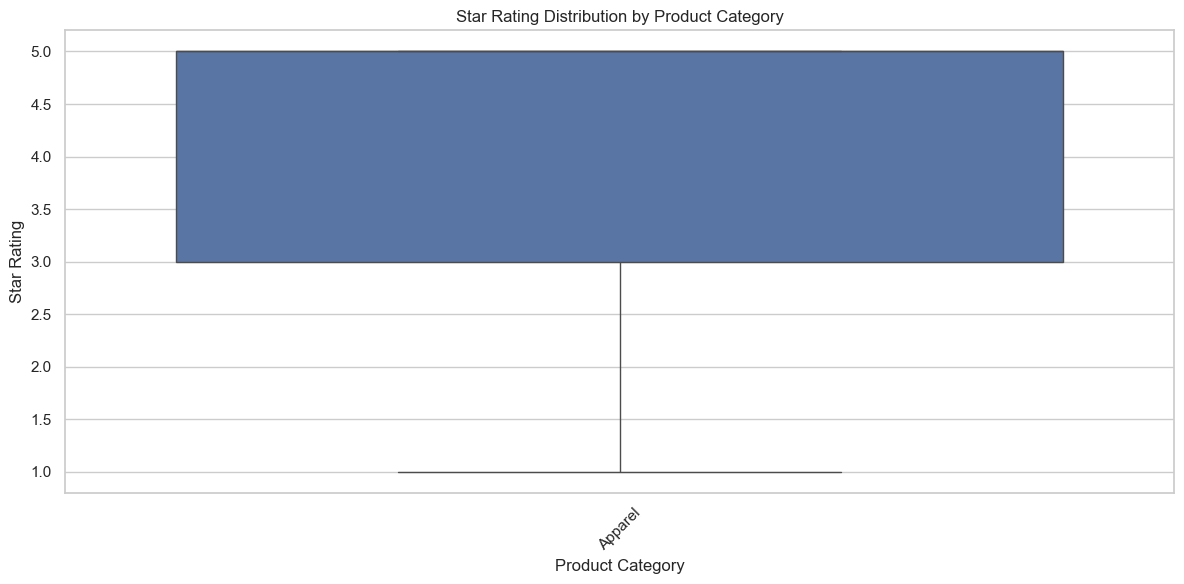

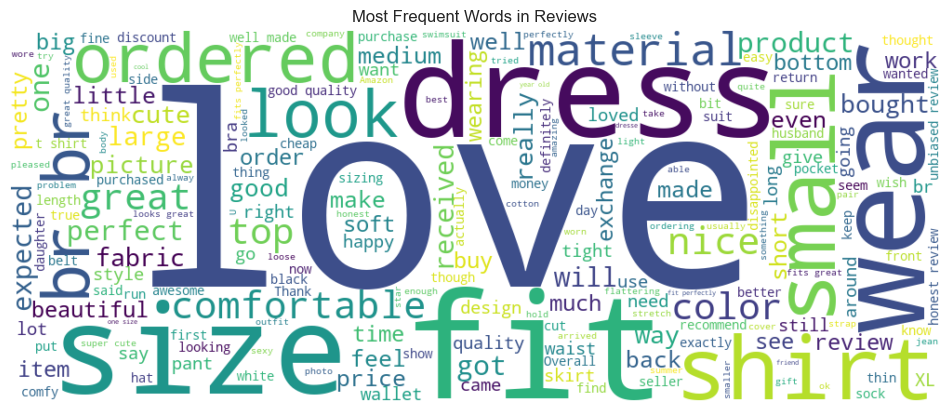

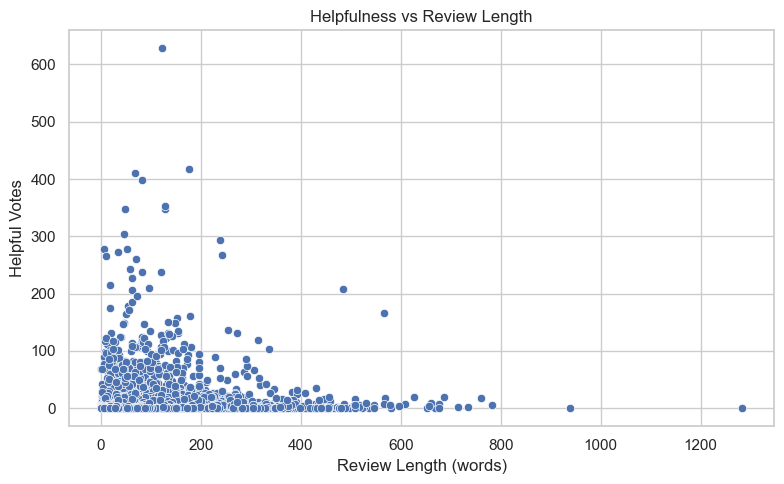

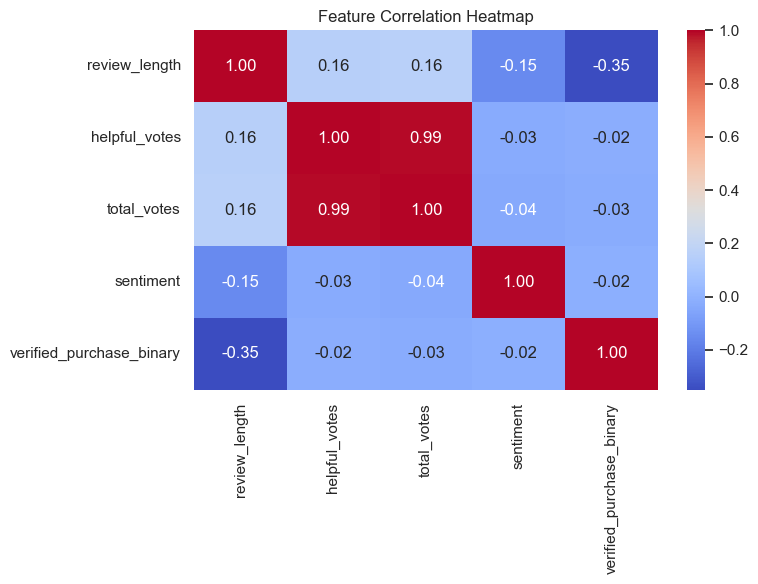

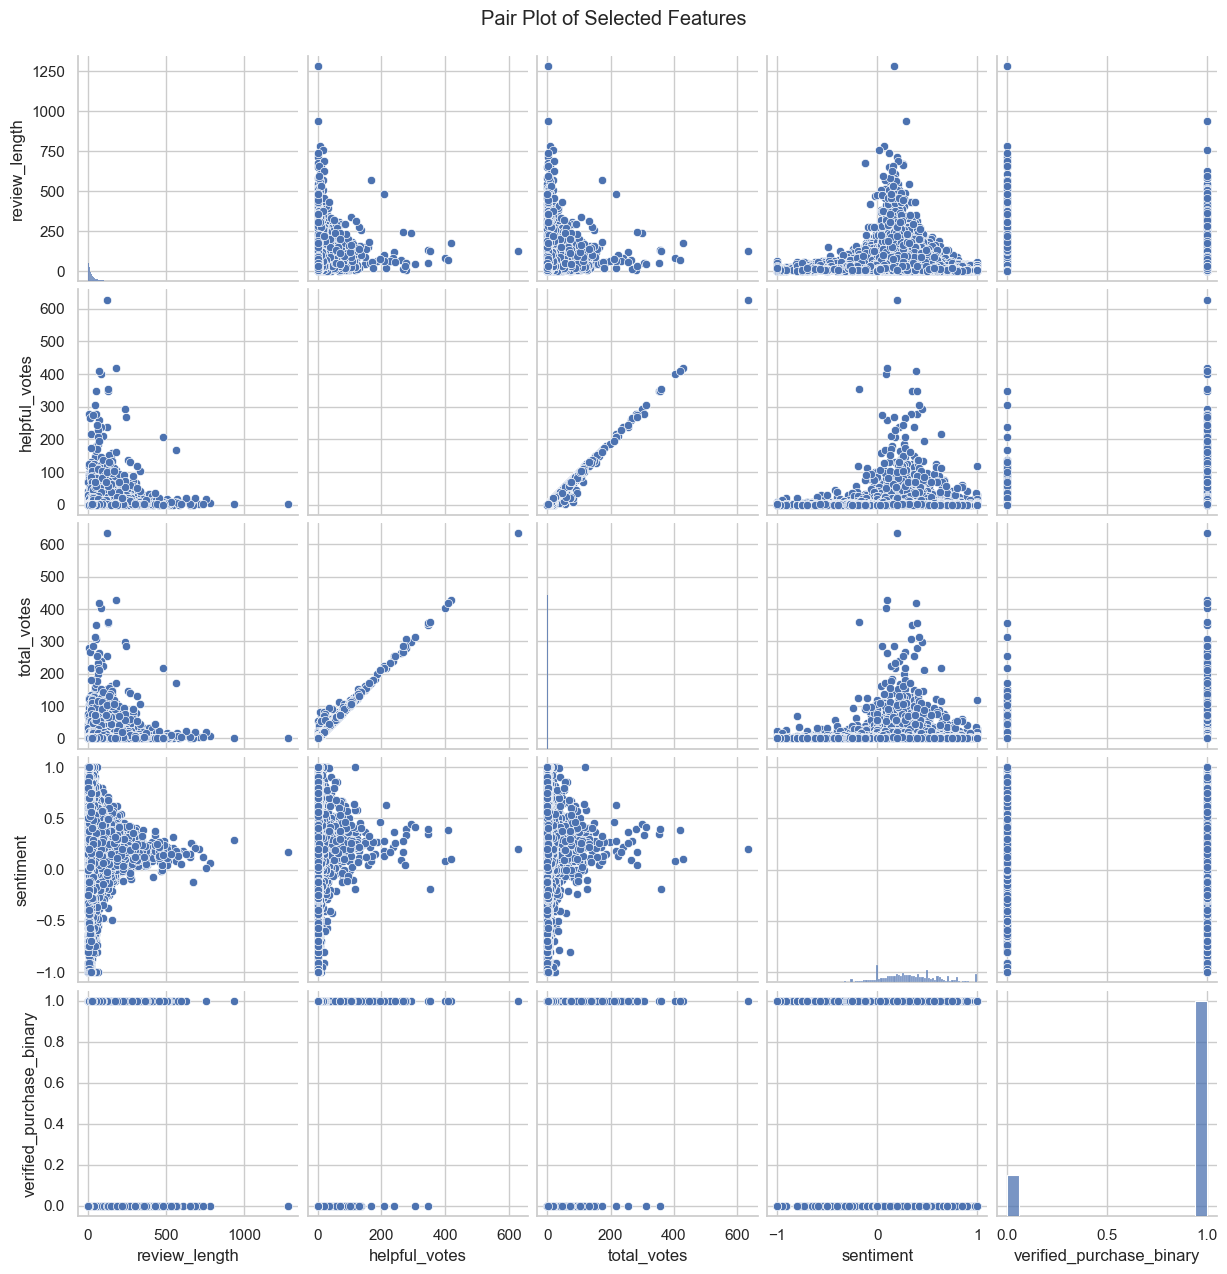

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  


Logistic Regression:
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00       756
     neutral       0.00      0.00      0.00      1719
    positive       0.75      1.00      0.86      7520

    accuracy                           0.75      9995
   macro avg       0.25      0.33      0.29      9995
weighted avg       0.57      0.75      0.65      9995


Decision Tree:
              precision    recall  f1-score   support

    negative       0.04      0.00      0.00       756
     neutral       0.23      0.03      0.05      1719
    positive       0.75      0.98      0.85      7520

    accuracy                           0.74      9995
   macro avg       0.34      0.34      0.30      9995
weighted avg       0.61      0.74      0.65      9995


Random Forest:
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00       756
     neutral       0.24      0.02      0.04      1719
    positive       0.

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  


KNN:
              precision    recall  f1-score   support

    negative       0.08      0.03      0.04       756
     neutral       0.20      0.11      0.14      1719
    positive       0.76      0.89      0.82      7520

    accuracy                           0.69      9995
   macro avg       0.35      0.34      0.33      9995
weighted avg       0.61      0.69      0.64      9995


SMOTE:
               precision    recall  f1-score   support

    negative       0.10      0.74      0.18       756
     neutral       0.21      0.33      0.26      1719
    positive       0.84      0.19      0.31      7520

    accuracy                           0.25      9995
   macro avg       0.38      0.42      0.25      9995
weighted avg       0.68      0.25      0.29      9995


Undersampling:
               precision    recall  f1-score   support

    negative       0.10      0.74      0.18       756
     neutral       0.21      0.34      0.26      1719
    positive       0.84      0.18      0.30

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  


AdaBoost:
               precision    recall  f1-score   support

    negative       0.00      0.00      0.00       756
     neutral       0.00      0.00      0.00      1719
    positive       0.75      1.00      0.86      7520

    accuracy                           0.75      9995
   macro avg       0.25      0.33      0.29      9995
weighted avg       0.57      0.75      0.65      9995


Gradient Boosting:
               precision    recall  f1-score   support

    negative       0.00      0.00      0.00       756
     neutral       0.33      0.00      0.00      1719
    positive       0.75      1.00      0.86      7520

    accuracy                           0.75      9995
   macro avg       0.36      0.33      0.29      9995
weighted avg       0.62      0.75      0.65      9995



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  


Stacked Model:
               precision    recall  f1-score   support

    negative       0.00      0.00      0.00       756
     neutral       0.00      0.00      0.00      1719
    positive       0.75      1.00      0.86      7520

    accuracy                           0.75      9995
   macro avg       0.25      0.33      0.29      9995
weighted avg       0.57      0.75      0.65      9995


Best Random Forest (GridSearch):
{'max_depth': None, 'n_estimators': 100}
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00       756
     neutral       0.22      0.02      0.03      1719
    positive       0.75      0.99      0.85      7520

    accuracy                           0.74      9995
   macro avg       0.32      0.33      0.30      9995
weighted avg       0.60      0.74      0.65      9995



In [5]:
# Section 2: Machine Learning Models

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from textblob import TextBlob

from sklearn.linear_model import LinearRegression, Lasso, Ridge, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import mean_squared_error, r2_score, classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Load and clean 
df = pd.read_csv("amazon_reviews_us_Apparel_v1_00.csv", nrows=50000)
df.dropna(subset=["review_body", "star_rating", "total_votes"], inplace=True)

# Feature Engineering 
df['review_length'] = df['review_body'].apply(lambda x: len(str(x).split()))
df['sentiment'] = df['review_body'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
df['helpfulness_score'] = df.apply(lambda row: row['helpful_votes'] / row['total_votes'] if row['total_votes'] > 0 else 0, axis=1)
df['verified_purchase_binary'] = df['verified_purchase'].map({'Y': 1, 'N': 0})
df['vine_binary'] = df['vine'].map({'Y': 1, 'N': 0})
df['sentiment_class'] = df['sentiment'].apply(lambda x: 'positive' if x > 0.1 else ('negative' if x < -0.1 else 'neutral'))

# TF-IDF for regression/classification 
tfidf = TfidfVectorizer(max_features=100)
tfidf_matrix = tfidf.fit_transform(df['review_body'].astype(str))
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf.get_feature_names_out())
df = pd.concat([df.reset_index(drop=True), tfidf_df.reset_index(drop=True)], axis=1)

# Normalize numerical features 
scaler = MinMaxScaler()
df[['total_votes_scaled', 'helpful_votes_scaled', 'review_length_scaled']] = scaler.fit_transform(
    df[['total_votes', 'helpful_votes', 'review_length']]
)

# Regression Models (predict star_rating)
X_reg = df[['review_length', 'sentiment', 'helpfulness_score', 'verified_purchase_binary']]
y_reg = df['star_rating']
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

def eval_reg(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    print(f"\n{name}:")
    print("R2:", r2_score(y_test, y_pred))
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

eval_reg("Linear", LinearRegression().fit(X_train_reg, y_train_reg), X_test_reg, y_test_reg)
eval_reg("Ridge", Ridge(alpha=1.0).fit(X_train_reg, y_train_reg), X_test_reg, y_test_reg)
eval_reg("Lasso", Lasso(alpha=0.1).fit(X_train_reg, y_train_reg), X_test_reg, y_test_reg)


# EDA & Visualization for Machine Learning
# 1. Rating distribution across product categories
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='product_category', y='star_rating')
plt.xticks(rotation=45)
plt.title("Star Rating Distribution by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Star Rating")
plt.tight_layout()
plt.show()

# 2. Word frequency visualization using WordCloud
text_corpus = ' '.join(df['review_body'].dropna().astype(str).tolist())
wordcloud = WordCloud(width=1000, height=400, background_color='white').generate(text_corpus)

plt.figure(figsize=(12, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Most Frequent Words in Reviews")
plt.show()

# 3. helpful_votes vs review_length scatterplot
plt.figure(figsize=(8, 5))
sns.scatterplot(x='review_length', y='helpful_votes', data=df)
plt.title("Helpfulness vs Review Length")
plt.xlabel("Review Length (words)")
plt.ylabel("Helpful Votes")
plt.tight_layout()
plt.show()

# 4. Heatmap and pair plot of selected features
selected_corr_features = ['review_length', 'helpful_votes', 'total_votes', 'sentiment', 'verified_purchase_binary']
plt.figure(figsize=(8, 6))
sns.heatmap(df[selected_corr_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

# Optional: Pairplot
sns.pairplot(df[selected_corr_features])
plt.suptitle("Pair Plot of Selected Features", y=1.02)
plt.show()


# Classification Models (predict sentiment_class)
X_clf = df[['review_length', 'helpfulness_score', 'verified_purchase_binary']]
le = LabelEncoder()
y_clf = le.fit_transform(df['sentiment_class'])
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier()
}

for name, model in models.items():
    model.fit(X_train_clf, y_train_clf)
    y_pred = model.predict(X_test_clf)
    print(f"\n{name}:\n{classification_report(y_test_clf, y_pred, target_names=le.classes_)}")

# Handle Imbalance 
# SMOTE
sm = SMOTE(random_state=42)
X_sm, y_sm = sm.fit_resample(X_train_clf, y_train_clf)
model_smote = LogisticRegression(max_iter=1000).fit(X_sm, y_sm)
print("\nSMOTE:\n", classification_report(y_test_clf, model_smote.predict(X_test_clf), target_names=le.classes_))

# Undersampling
under = RandomUnderSampler(random_state=42)
X_under, y_under = under.fit_resample(X_train_clf, y_train_clf)
model_under = LogisticRegression(max_iter=1000).fit(X_under, y_under)
print("\nUndersampling:\n", classification_report(y_test_clf, model_under.predict(X_test_clf), target_names=le.classes_))

# Class Weights
weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train_clf), y=y_train_clf)
class_weight_dict = {i: weights[i] for i in range(len(le.classes_))}
model_weighted = LogisticRegression(max_iter=1000, class_weight=class_weight_dict).fit(X_train_clf, y_train_clf)
print("\nClass Weights:\n", classification_report(y_test_clf, model_weighted.predict(X_test_clf), target_names=le.classes_))

# Ensemble Models 
# Bagging - Random Forest
rf = RandomForestClassifier(n_estimators=100).fit(X_train_clf, y_train_clf)
print("\nRandom Forest:\n", classification_report(y_test_clf, rf.predict(X_test_clf), target_names=le.classes_))

# Boosting - AdaBoost & Gradient Boosting
ab = AdaBoostClassifier(n_estimators=50).fit(X_train_clf, y_train_clf)
gb = GradientBoostingClassifier(n_estimators=100).fit(X_train_clf, y_train_clf)
print("\nAdaBoost:\n", classification_report(y_test_clf, ab.predict(X_test_clf), target_names=le.classes_))
print("\nGradient Boosting:\n", classification_report(y_test_clf, gb.predict(X_test_clf), target_names=le.classes_))

# Stacking
base_models = [
    ('rf', RandomForestClassifier(n_estimators=50)),
    ('dt', DecisionTreeClassifier()),
    ('lr', LogisticRegression(max_iter=1000))
]
stack = StackingClassifier(estimators=base_models, final_estimator=LogisticRegression())
stack.fit(X_train_clf, y_train_clf)
print("\nStacked Model:\n", classification_report(y_test_clf, stack.predict(X_test_clf), target_names=le.classes_))

# GridSearchCV for Hyperparameter Tuning 
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20]
}
grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3, scoring='f1_macro')
grid.fit(X_train_clf, y_train_clf)
print("\nBest Random Forest (GridSearch):")
print(grid.best_params_)
print(classification_report(y_test_clf, grid.predict(X_test_clf), target_names=le.classes_))


In [6]:
# Section 3: Deep Learning and Advanced Models

import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from textblob import TextBlob

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Embedding, SimpleRNN, LSTM, GRU, Conv1D, MaxPooling1D, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l1_l2
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Load review data
df = pd.read_csv("amazon_reviews_us_Apparel_v1_00.csv", nrows=50000)
df.dropna(subset=["review_body", "star_rating", "total_votes"], inplace=True)
df = df[df['star_rating'] != 3]

# Feature engineering
df['review_length'] = df['review_body'].apply(lambda x: len(str(x).split()))
df['sentiment'] = df['review_body'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
df['helpfulness_score'] = df.apply(lambda r: r['helpful_votes'] / r['total_votes'] if r['total_votes'] > 0 else 0, axis=1)
df['verified_purchase_binary'] = df['verified_purchase'].map({'Y': 1, 'N': 0})
df['label'] = df['star_rating'].apply(lambda x: 1 if x >= 4 else 0)

# DNN Model (Regression)
X = df[['review_length', 'sentiment', 'helpfulness_score', 'verified_purchase_binary']]
y = df['star_rating']
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

dnn_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_scaled.shape[1],), kernel_regularizer=l1_l2(0.01)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu', kernel_regularizer=l1_l2(0.01)),
    BatchNormalization(),
    Dropout(0.2),
    Dense(1)
])

dnn_model.compile(optimizer=Adam(learning_rate=1e-3), loss='mean_squared_error', metrics=['mae'])
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
dnn_model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=15, batch_size=32, callbacks=[early_stop])
y_pred = dnn_model.predict(X_test).flatten()
print(f"\nDNN Regression R2: {r2_score(y_test, y_pred):.4f}, RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

# CNN with ResNet (Image Classification)
label_df = pd.read_csv("image_labels.csv")
label_df['filepath'] = label_df['filename'].apply(lambda x: f"/mnt/data/unzipped_images/Images/{x}")
train_df, val_df = train_test_split(label_df, test_size=0.2, stratify=label_df['label'], random_state=42)

train_gen = ImageDataGenerator(rescale=1./255, rotation_range=20, zoom_range=0.2, horizontal_flip=True).flow_from_dataframe(
    train_df, x_col='filepath', y_col='label', target_size=(128, 128), class_mode='categorical', batch_size=32)
val_gen = ImageDataGenerator(rescale=1./255).flow_from_dataframe(
    val_df, x_col='filepath', y_col='label', target_size=(128, 128), class_mode='categorical', batch_size=32)

resnet = ResNet50(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
resnet.trainable = False
cnn_model = Sequential([
    resnet,
    GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(train_gen.num_classes, activation='softmax')
])
cnn_model.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
cnn_model.fit(train_gen, validation_data=val_gen, epochs=10, callbacks=[EarlyStopping(patience=3)])
cnn_model.save("resnet_model")

# Transfer learning: fine-tune ResNet
resnet.trainable = True
cnn_model.compile(optimizer=Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])
cnn_model.fit(train_gen, validation_data=val_gen, epochs=10, callbacks=[EarlyStopping(patience=3)])

# TensorFlow Lite Export
converter = tf.lite.TFLiteConverter.from_saved_model("resnet_model")
tflite_model = converter.convert()
with open("resnet_model.tflite", "wb") as f:
    f.write(tflite_model)

# Sequential Text Models (RNN, LSTM, GRU, CRNN)
tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(df['review_body'])
sequences = tokenizer.texts_to_sequences(df['review_body'])
X_seq = pad_sequences(sequences, maxlen=200)
y_seq = df['label'].values
X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(X_seq, y_seq, test_size=0.2, random_state=42)

def build_rnn(cell):
    model = Sequential([
        Embedding(10000, 64, input_length=200),
        cell(64),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

model_rnn = build_rnn(SimpleRNN)
model_lstm = build_rnn(LSTM)
model_gru = build_rnn(GRU)

model_rnn.fit(X_train_seq, y_train_seq, epochs=3, validation_split=0.1)
model_lstm.fit(X_train_seq, y_train_seq, epochs=3, validation_split=0.1)
model_gru.fit(X_train_seq, y_train_seq, epochs=3, validation_split=0.1)

# CRNN
model_crnn = Sequential([
    Embedding(10000, 64, input_length=200),
    Conv1D(64, 5, activation='relu'),
    MaxPooling1D(2),
    LSTM(64),
    Dense(1, activation='sigmoid')
])
model_crnn.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model_crnn.fit(X_train_seq, y_train_seq, epochs=3, validation_split=0.1)


# PyTorch Comparison
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y.values.reshape(-1, 1), dtype=torch.float32)
dataset = TensorDataset(X_tensor, y_tensor)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(4, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

model_pt = SimpleNN()
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model_pt.parameters(), lr=0.01)

for epoch in range(5):
    for xb, yb in loader:
        pred = model_pt(xb)
        loss = loss_fn(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1} Loss: {loss.item():.4f}")


from ultralytics import YOLO

# Load pretrained YOLOv8 model
yolo_model = YOLO("yolov8n.pt")

# Train on your dataset
yolo_model.train(data="yolo_dataset.yaml", epochs=25, imgsz=640)

# Evaluate
yolo_model.val()

# Export to TensorFlow Lite
yolo_model.export(format="tflite")


2025-08-03 18:19:48.776675: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.

A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/ipykernel_launcher.py",

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/ipyk

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.




A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/ipyk

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



ImportError: numpy.core._multiarray_umath failed to import

ImportError: numpy.core.umath failed to import

In [1]:

#section 4
#Imports 
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
import faiss
from rapidfuzz import process, fuzz
import openai
import gradio as gr
from datasets import Dataset

# Preprocessing Product Titles 
df = pd.read_csv("amazon_reviews_us_Apparel_v1_00.csv", usecols=["product_id", "product_title", "product_category"])
df.dropna(subset=["product_title", "product_category"], inplace=True)

# Limit for testing
df = df.head(1000)

df["clean_title"] = df["product_title"].str.lower().str.replace(r'[^\w\s]', '', regex=True)


# embedding & FAISS Setup
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(df["clean_title"].tolist(), show_progress_bar=True)
faiss_index = faiss.IndexFlatL2(embeddings.shape[1])
faiss_index.add(np.array(embeddings).astype("float32"))
product_metadata = df[["product_id", "product_title", "product_category"]].reset_index(drop=True)

# Fuzzy Matching Fallback
def fuzzy_match_product(query, choices, top_n=3):
    return process.extract(query, choices, scorer=fuzz.token_sort_ratio, limit=top_n)

#LLM Prompt Creation
def create_prompt(product_title, product_category):
    return f"""
You are a marketing copywriter for an e-commerce store.

Write a high-quality, persuasive product description.

Product Title: {product_title}
Category: {product_category}

Description:"""

# LLM Completion Call
def generate_description(prompt, temperature=0.8, top_p=0.9):
    response = openai.ChatCompletion.create(
        model="gpt-4",
        messages=[{"role": "user", "content": prompt}],
        temperature=temperature,
        top_p=top_p
    )
    return response.choices[0].message["content"].strip()

# RAG search FAISS for Related Products 
def search_faiss(query, index, df_metadata, top_k=5):
    query_embedding = model.encode([query])
    D, I = index.search(np.array(query_embedding).astype("float32"), top_k)
    return df_metadata.iloc[I[0]].reset_index(drop=True)

# RAG Build Prompt from Retrieved Context
def build_rag_prompt(query, retrieved_df):
    context = "\n".join([f"- {row['product_title']} ({row['product_category']})" for _, row in retrieved_df.iterrows()])
    return f"""You are a product description generator.

Customer Query: "{query}"

Relevant Products:
{context}

Description:"""

#RAG Generation Function
def rag_generate(query, faiss_index, metadata_df):
    retrieved_df = search_faiss(query, faiss_index, metadata_df)
    prompt = build_rag_prompt(query, retrieved_df)
    return generate_description(prompt)

# Fine-Tuning Dataset Prep (Hugging Face)
df_train = pd.DataFrame({
    "instruction": "Generate a product description",
    "input": df["product_title"] + " (" + df["product_category"] + ")",
    "output": ["Sample description here."] * len(df)  # Replace with actual or LLM-generated descriptions
})
dataset = Dataset.from_pandas(df_train)
dataset.to_json("product_data.jsonl")

# Gradio Web Interface 
def run_app(title, category, feedback=None):
    prompt = create_prompt(title, category)
    return generate_description(prompt)

interface = gr.Interface(
    fn=run_app,
    inputs=[
        gr.Textbox(label="Product Title"),
        gr.Textbox(label="Product Category", value="Apparel"),
        gr.Textbox(label="Your Feedback (Optional)")
    ],
    outputs="text",
    title="AI Product Description Generator",
    description="Enter a product title and category to generate a persuasive description."
)

# Launch App 
interface.launch()


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-08-03 19:06:33.682642: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Creating json from Arrow format: 100%|██████████| 1/1 [00:00<00:00, 126.62ba/s]


Running on local URL:  http://127.0.0.1:7860

To create a public link, set `share=True` in `launch()`.


IMPORTANT: You are using gradio version 3.50.2, however version 4.44.1 is available, please upgrade.
--------
